In [1]:
library(WGCNA)
# Allow multi-threading
enableWGCNAThreads()
library(DESeq2)
library(TCGAbiolinks)
library(biomaRt)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(ggplot2)
library(GEOquery)
library(miRBaseConverter)
library(sva)
library(readr)
library(dplyr)
library(tidyr)
library(EnhancedVolcano)
library(biomaRt)
library(edgeR)
library(tibble)

# EX TAIWANESE_CONSTRUCTIONS
# NOW PARAMETRIZED FOR BOTH TAIWAN AND WHITE COHORTS, SIMPLER

Loading required package: dynamicTreeCut

Loading required package: fastcluster


Attaching package: ‘fastcluster’


The following object is masked from ‘package:stats’:

    hclust



Attaching package: ‘WGCNA’


The following object is masked from ‘package:stats’:

    cor




Allowing parallel execution with up to 11 working processes.


Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [2]:
prepare_module_dist <- function(net_obj, candidate_ids, label_type) {
  # Extraer módulos de los candidatos
  mod_assignment <- net_obj$colors[candidate_ids]
  
  df <- as.data.frame(table(mod_assignment))
  colnames(df) <- c("ModuleID", "Count")
  
  # Convertir números a colores de WGCNA
  df$Color <- labels2colors(as.numeric(as.character(df$ModuleID)))
  
  df <- df %>% arrange(desc(Count))
  df$Type <- label_type
  return(df)
}

In [ ]:
cohort <- "TAIWAN" # TAIWAN O WHITE
if (cohort == "TAIWAN") {
    config <- list(
        wd = "/home/seba/github_repos/crc_weighted_network/taiwanese_cohort/count_matrices_by_geneid",
        rna_base_counts = "RNA_merged_counts_filtered.csv",
        mirna_base_counts = "miRNA_merged_counts_filtered.csv",
        row_names_in_metadata = 1,
        metadata_file = "all_metadata_taiwan.csv",
        col_for_datatype = "Assay.Type",
        rna_datatype = "RNA-Seq",
        mirna_datatype = "miRNA-Seq",
        external_col = "PHENOTYPE",
        contrast_for_dea = c("PHENOTYPE", "neoplastic", "adjacent normal"),
        vrna_network_dir = "rna_pooled_tmm",
        mirna_network_dir = "mirna_pooled_tmm",
        #rna_network_dir = "rna_tumor_tmm",
        #rna_network_dir = "rna_normal_tmm",
        rna_kme_limit = 0,
        rna_kme_p_limit = 1,
        rna_gs_limit = 0.4,
        rna_gs_p_limit = 1e-02,
        mirna_kme_limit = 0,
        mirna_kme_p_limit = 1,
        mirna_gs_limit = 0.4,
        mirna_gs_p_limit = 1e-02
    )
} else if (cohort == "WHITE") {
    config <- list(
        wd = "/home/seba/github_repos/crc_weighted_network/cohort_white/count_matrices_white_byFILENAME",
        rna_base_counts = "RNA_merged_filtered.csv",
        mirna_base_counts = "mirna_new_filtered_merged.csv",
        row_names_in_metadata = 2,
        metadata_file = "gdc_sample_sheet.2026-01-21_GENES+MIRNAISOFORMS.csv",
        col_for_datatype = "Data.Type",
        rna_datatype = "Gene Expression Quantification",
        mirna_datatype = "Isoform Expression Quantification",
        external_col = "Tissue.Type",
        contrast_for_dea = c("Tissue.Type", "Tumor", "Normal"),
        rna_network_dir = "2_RNA_TMM_T_merged_counts",
        #rna_network_dir = "rna_pooled_tmm0.4",
        #rna_network_dir = "rna_tumor_tmm0.4",
        #rna_network_dir = "rna_normal_tmm0.4", 
        mirna_network_dir = "1_newMIRNA_TMM_T_merged_counts",
        #mirna_network_dir = "mirna_pooled_tmm",
        rna_kme_limit = 0,
        rna_kme_p_limit = 1,
        rna_gs_limit = 0.4,
        rna_gs_p_limit = 1e-02,
        mirna_kme_limit = 0,
        mirna_kme_p_limit = 1,
        mirna_gs_limit = 0.4,
        mirna_gs_p_limit = 1e-02
    )
}

In [19]:
# set working directory
setwd(config$wd)

In [5]:
# Load RNA and miRNA data, ENSURE THESE COME PRE-FILTERED (remove low counts)
rna_counts <- read.csv(config$rna_base_counts, row.names = 1, sep=",", header=TRUE, check.names = FALSE)
mirna_counts <- read.csv(config$mirna_base_counts, row.names = 1, sep=",", header=TRUE, check.names = FALSE)


# Load metadata
metadata <- read.csv(config$metadata_file, row.names = config$row_names_in_metadata, header=TRUE)
rna_metadata <- metadata[metadata[[config$col_for_datatype]] == config$rna_datatype, ]
mirna_metadata <- metadata[metadata[[config$col_for_datatype]] == config$mirna_datatype, ]

# ensure order
rna_metadata <- rna_metadata[colnames(rna_counts), ]
mirna_metadata <- mirna_metadata[colnames(mirna_counts), ]

# write also the same rna and mirna raw counts but transposed
write.csv(as.data.frame(rna_counts), file="RNA_merged_T_filtered.csv")
write.csv(as.data.frame(mirna_counts), file="miRNA_merged_T_filtered.csv")

In [6]:
# Do the differential expression analysis
dds <- DESeqDataSetFromMatrix(countData = rna_counts,
                    colData = rna_metadata,
                    design = as.formula(paste0("~", config$external_col)))

dds <- DESeq(dds)
res <- results(dds, contrast=config$contrast_for_dea)
res_ordered <- res[order(res$padj), ]

df_rna = res_ordered
df_rna$Category <- "Not significant" # Criteria can be changed
df_rna[which(df_rna$log2FoldChange > 2 & df_rna$padj <= 0.001),]$Category <- "Up-regulated"
df_rna[which(df_rna$log2FoldChange < -2 & df_rna$padj <= 0.001),]$Category <- "Down-regulated"

#df_rna <- df_rna[df_rna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 1722 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [7]:
# Crear el objeto y normalizar

group <- factor(rna_metadata[[config$external_col]])
dge <- DGEList(counts = rna_counts, group = group)
#keep <- filterByExpr(dge) # Filtro de genes con baja expresión
#dge <- dge[keep, , keep.lib.sizes=FALSE]
dge <- calcNormFactors(dge, method="TMM") # Normalización TMM

# Estimar dispersión y ejecutar el test
dge <- estimateDisp(dge)
et <- exactTest(dge)

# Extraer tabla completa
res_edger_rna <- topTags(et, n=Inf)$table

# Filtrar por tus criterios (ejemplo: p-adj < 0.01 y |logFC| > 2)
#degs_edger <- row.names(res_edger[res_edger$FDR < 0.001 & abs(res_edger$logFC) > 2, ])

Using classic mode.



In [8]:
res_edger_rna$Category <- "Not significant" # Criteria can be changed
res_edger_rna[which(res_edger_rna$logFC > 2 & res_edger_rna$FDR <= 0.001),]$Category <- "Up-regulated"
res_edger_rna[which(res_edger_rna$logFC < -2 & res_edger_rna$FDR <= 0.001),]$Category <- "Down-regulated"

In [9]:
# Intersection between DESeq2 and edgeR results
degs_deseq2 <- row.names(df_rna[df_rna$Category != "Not significant", ])
degs_edger <- row.names(res_edger_rna[res_edger_rna$Category != "Not significant", ])
degs_intersection <- intersect(degs_deseq2, degs_edger)
# unique for DESeq2
degs_deseq2_unique <- setdiff(degs_deseq2, degs_edger)
# unique for edgeR
degs_edger_unique <- setdiff(degs_edger, degs_deseq2)

Loading required package: grid



Loading required package: futile.logger


Attaching package: ‘futile.logger’


The following object is masked from ‘package:mgcv’:

    scat




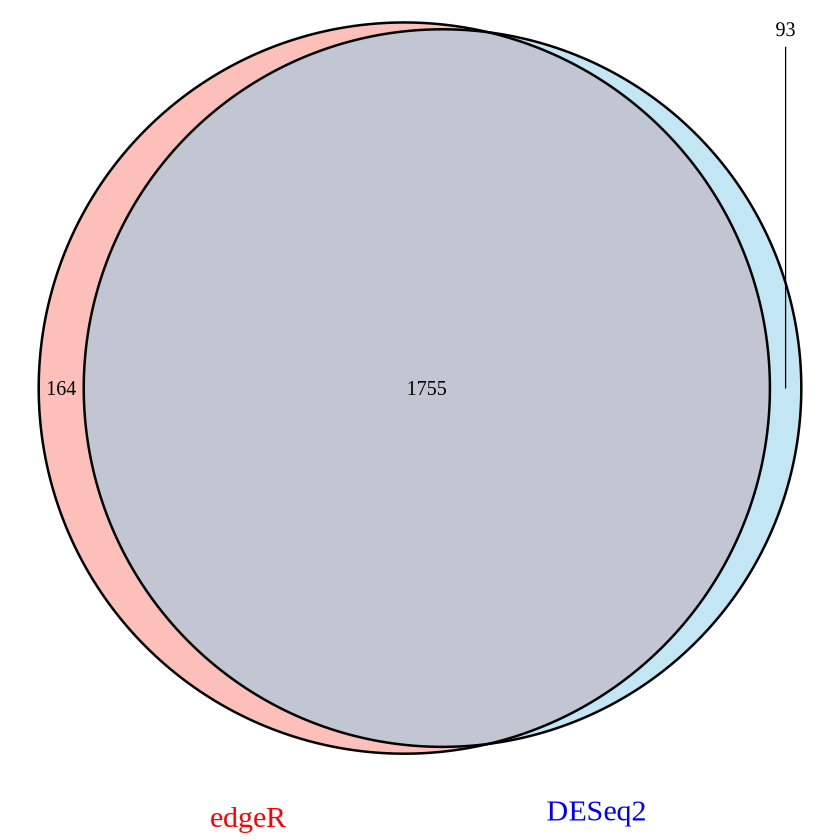

In [10]:
# Venn diagram between DESeq2 and edgeR results
library(VennDiagram)
venn.plot <- venn.diagram(
  x = list(DESeq2 = degs_deseq2, edgeR = degs_edger),
  filename = NULL,
  fill = c("skyblue", "salmon"),
  alpha = 0.5,
  cat.col = c("blue", "red"),
  cat.cex = 1.5,
  cat.pos = c(-20, 20),
  cat.dist = c(0.05, 0.05)
)
grid.newpage()
grid.draw(venn.plot)

In [11]:
genes_comunes <- intersect(rownames(df_rna), rownames(res_edger_rna))

# 2. Creamos una copia de la tabla de DESeq2 para no perder los datos originales
res_deseq2_consenso <- df_rna

# 3. Aplicamos la lógica de comparación
# Usamos sapply o un bucle lógico sobre los genes comunes
res_deseq2_consenso$Category <- ifelse(
  rownames(res_deseq2_consenso) %in% genes_comunes, 
  ifelse(
    res_deseq2_consenso$Category == res_edger_rna[rownames(res_deseq2_consenso), "Category"],
    res_deseq2_consenso$Category, # Si son iguales, se queda igual
    "Not significant"             # Si son diferentes, cambia a Not Significant
  ),
  "Not significant" # Si el gen no está en la tabla de edgeR, también es Not Significant
)

# 4. Verificamos cuántos genes sobrevivieron al consenso
table(res_deseq2_consenso$Category)


 Down-regulated Not significant    Up-regulated 
            880           17087             875 

In [12]:
df_rna <- res_deseq2_consenso

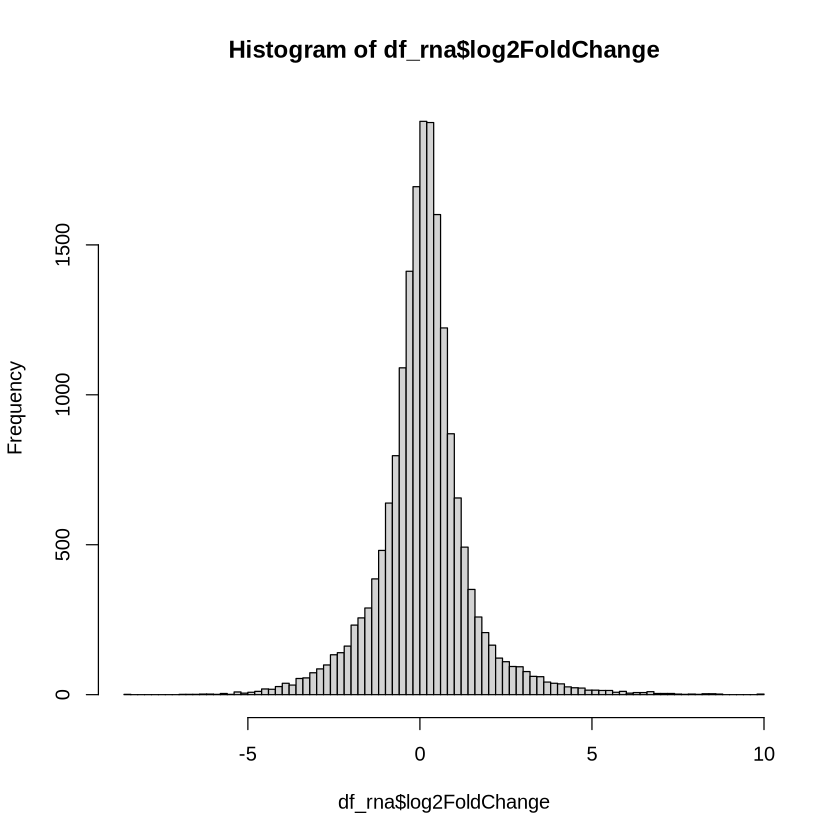

In [13]:
hist(df_rna$log2FoldChange, breaks = 100)

In [13]:
svg(paste0("volcanorna_", cohort, ".svg"))
EnhancedVolcano(df_rna,
                lab = rownames(df_rna), # Your gene names
                x = 'log2FoldChange',   # Your log2 fold-change column
                y = 'padj',           # Your p-value column
                title = 'RNA differential expression',
                pCutoff = 0.001,
                FCcutoff = 2,
                labSize = 0)
dev.off()

ERROR: Error: object 'df_rna' not found


In [15]:
# DESeq2 on mirna data now
mirna_merged_raw <- as.matrix(mirna_counts)
dds_mirna <- DESeqDataSetFromMatrix(countData = mirna_merged_raw,
                colData = mirna_metadata,
                design = as.formula(paste0("~", config$external_col)))

dds_mirna <- DESeq(dds_mirna)
res_mirna <- results(dds_mirna, contrast=config$contrast_for_dea)
res_mirna = res_mirna[order(res_mirna$padj), ]
res_mirna <- res_mirna[!is.na(res_mirna$padj), ]

res_mirna_ordered <- res_mirna[order(res_mirna$padj), ]
df_mirna = res_mirna_ordered
df_mirna$Category <- "Not significant" # Criteria can be changed
df_mirna[which(df_mirna$log2FoldChange > 2 & df_mirna$padj <= 0.001),]$Category <- "Up-regulated"
df_mirna[which(df_mirna$log2FoldChange < -2 & df_mirna$padj <= 0.001),]$Category <- "Down-regulated"

if (cohort == "TAIWAN") {
    new_mirnanames <- miRNA_NameToAccession(rownames(df_mirna),version = "v22")
    rownames(df_mirna) <- new_mirnanames$Accession
}

#df_mirna <- df_mirna[df_mirna$Category != "Not significant", ]

Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 34 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



In [16]:
# edgeR con datos de miRNA
group_mirna <- factor(mirna_metadata[[config$external_col]])
y_mirna <- DGEList(counts = mirna_counts, group = group_mirna)
#keep_mirna <- filterByExpr(y_mirna) # Filtro de genes con baja expresión

#y_mirna <- y_mirna[keep_mirna, , keep.lib.sizes=FALSE]
y_mirna <- calcNormFactors(y_mirna, method="TMM") # Normalización TMM

# Estimar dispersión y ejecutar el test
y_mirna <- estimateDisp(y_mirna)
et <- exactTest(y_mirna)

# Extraer tabla completa
res_edger_mirna <- topTags(et, n=Inf)$table

# Filtrar por tus criterios (ejemplo: p-adj < 0.01 y |logFC| > 2)
#degs_edger <- row.names(res_edger[res_edger$FDR < 0.001 & abs(res_edger$logFC) > 2, ])

Using classic mode.



In [17]:
res_edger_mirna$Category <- "Not significant" # Criteria can be changed
res_edger_mirna[which(res_edger_mirna$logFC > 2 & res_edger_mirna$FDR <= 0.001),]$Category <- "Up-regulated"
res_edger_mirna[which(res_edger_mirna$logFC < -2 & res_edger_mirna$FDR <= 0.001),]$Category <- "Down-regulated"

In [18]:
if (cohort == "TAIWAN") {
    new_mirnanames_edger <- miRNA_NameToAccession(rownames(res_edger_mirna),version = "v22")
    rownames(res_edger_mirna) <- new_mirnanames_edger$Accession
}

In [19]:
# Intersection between DESeq2 and edgeR results
degs_deseq2 <- row.names(df_mirna[df_mirna$Category != "Not significant", ])
degs_edger <- row.names(res_edger_mirna[res_edger_mirna$Category != "Not significant", ])
degs_intersection <- intersect(degs_deseq2, degs_edger)
# unique for DESeq2
degs_deseq2_unique <- setdiff(degs_deseq2, degs_edger)
# unique for edgeR
degs_edger_unique <- setdiff(degs_edger, degs_deseq2)

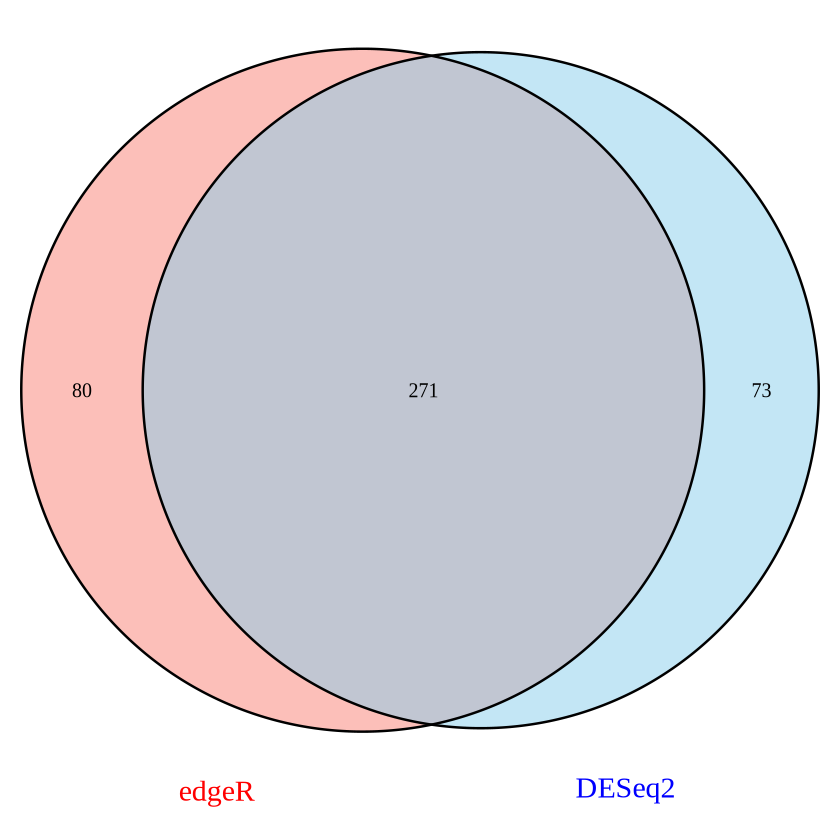

In [20]:
# Venn diagram between DESeq2 and edgeR results
library(VennDiagram)
venn.plot <- venn.diagram(
  x = list(DESeq2 = degs_deseq2, edgeR = degs_edger),
  filename = NULL,
  fill = c("skyblue", "salmon"),
  alpha = 0.5,
  cat.col = c("blue", "red"),
  cat.cex = 1.5,
  cat.pos = c(-20, 20),
  cat.dist = c(0.05, 0.05)
)
grid.newpage()
grid.draw(venn.plot)

In [21]:
genes_comunes <- intersect(rownames(df_mirna), rownames(res_edger_mirna))

# 2. Creamos una copia de la tabla de DESeq2 para no perder los datos originales
res_deseq2_consenso <- df_mirna

# 3. Aplicamos la lógica de comparación
# Usamos sapply o un bucle lógico sobre los genes comunes
res_deseq2_consenso$Category <- ifelse(
  rownames(res_deseq2_consenso) %in% genes_comunes, 
  ifelse(
    res_deseq2_consenso$Category == res_edger_mirna[rownames(res_deseq2_consenso), "Category"],
    res_deseq2_consenso$Category, # Si son iguales, se queda igual
    "Not significant"             # Si son diferentes, cambia a Not Significant
  ),
  "Not significant" # Si el gen no está en la tabla de edgeR, también es Not Significant
)

# 4. Verificamos cuántos genes sobrevivieron al consenso
table(res_deseq2_consenso$Category)


 Down-regulated Not significant    Up-regulated 
            118             936             153 

In [22]:
df_mirna <- res_deseq2_consenso

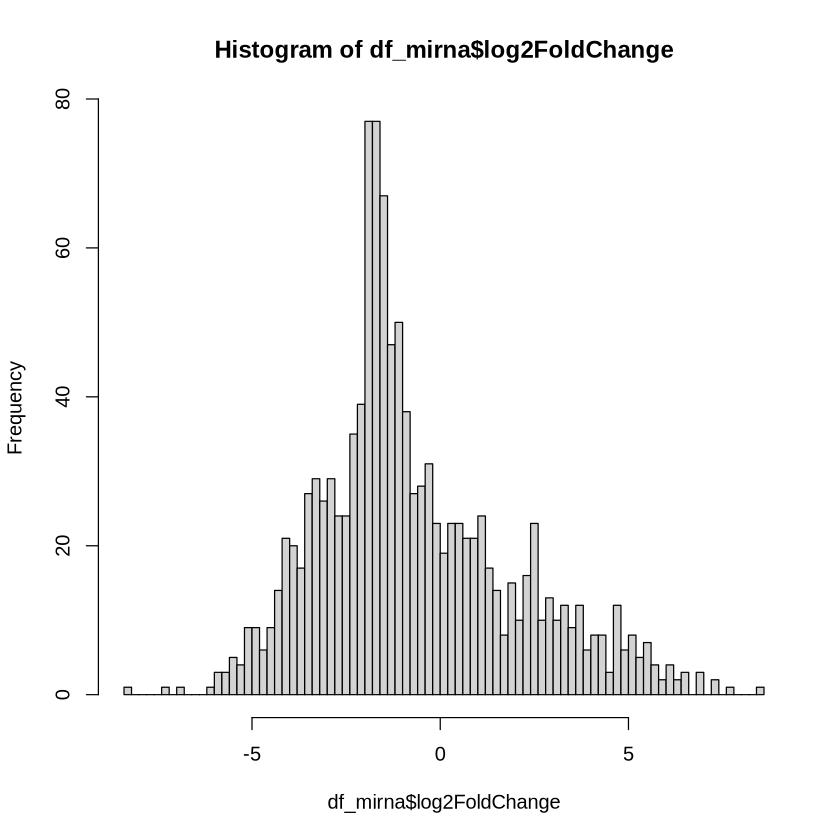

In [23]:
hist(df_mirna$log2FoldChange, breaks = 100)

In [24]:
svg(paste0("volcanomirna_", cohort, ".svg"))
EnhancedVolcano(df_mirna,
                lab = rownames(df_mirna), # Your gene names
                x = 'log2FoldChange',   # Your log2 fold-change column
                y = 'padj',           # Your p-value column
                title = 'miRNA differential expression',
                pCutoff = 0.001,
                FCcutoff = 2,
                labSize = 0)
dev.off()

pdf 
  2

In [25]:
# write rna and mirna results to tsv files
write.table(df_rna, file="DESeq2_RNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)
write.table(df_mirna, file="DESeq2_miRNA_results.tsv", sep="\t", quote=FALSE, row.names=TRUE, col.names = NA)

In [26]:
# save DESeq2 normalized counts too
norm_counts <- counts(dds, normalized=TRUE)
vsd_counts <- varianceStabilizingTransformation(dds, blind = TRUE)

norm_counts_mirna <- counts(dds_mirna, normalized=TRUE)
vsd_counts_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)

#rlog_counts <- rlog(dds, blind=TRUE)
#rlog_counts_mirna <- rlog(dds_mirna, blind=TRUE)

write.csv(t(as.data.frame(norm_counts)), file="RNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts)), file="RNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts)), file="rna_rlog_counts.csv")

write.csv(t(as.data.frame(norm_counts_mirna)), file="miRNA_merged_T_deseq2.csv")
write.csv(t(assay(vsd_counts_mirna)), file="miRNA_merged_T_vsd.csv")
#write.csv((assay(rlog_counts_mirna)), file="mirna_rlog_counts.csv")

In [27]:
vsd <- varianceStabilizingTransformation(dds, blind = TRUE)
pca <- prcomp(t(assay(vsd)), scale. = FALSE)
percentVar <- (pca$sdev^2) / sum(pca$sdev^2)

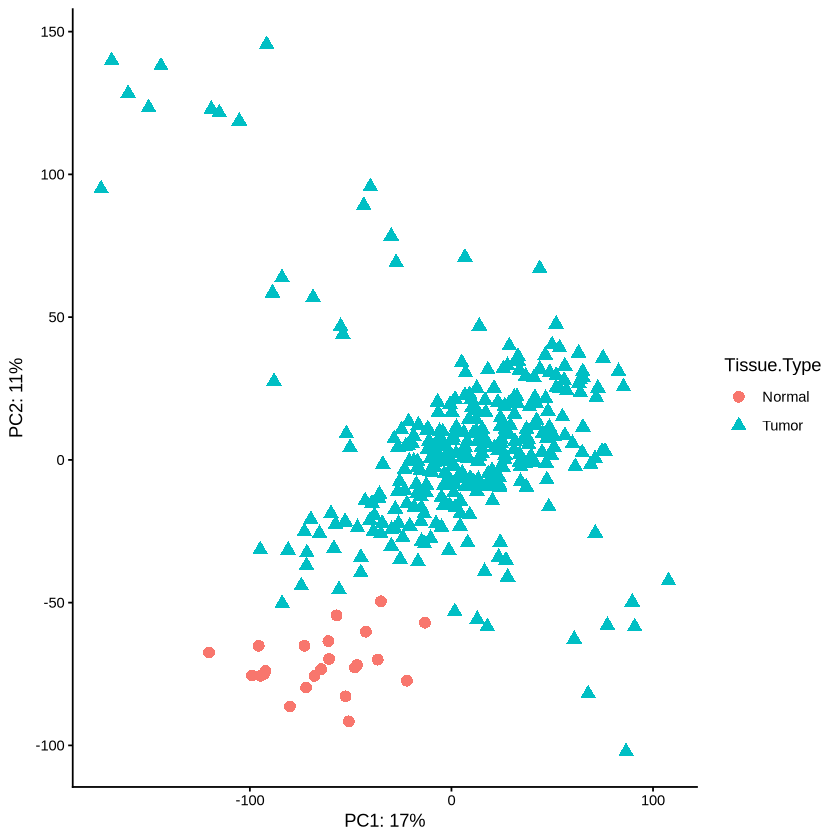

In [28]:
pca_df <- data.frame(
  PC1 = pca$x[,1],
  PC2 = pca$x[,2],
  rna_metadata
)

ggplot(pca_df, aes(PC1, PC2,
                   color = .data[[config$external_col]],
                   shape = .data[[config$external_col]])) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [29]:
vsd_mirna <- varianceStabilizingTransformation(dds_mirna, blind = TRUE)
pca_mirna <- prcomp(t(assay(vsd_mirna)), scale. = FALSE)
percentVar <- (pca_mirna$sdev^2) / sum(pca_mirna$sdev^2)

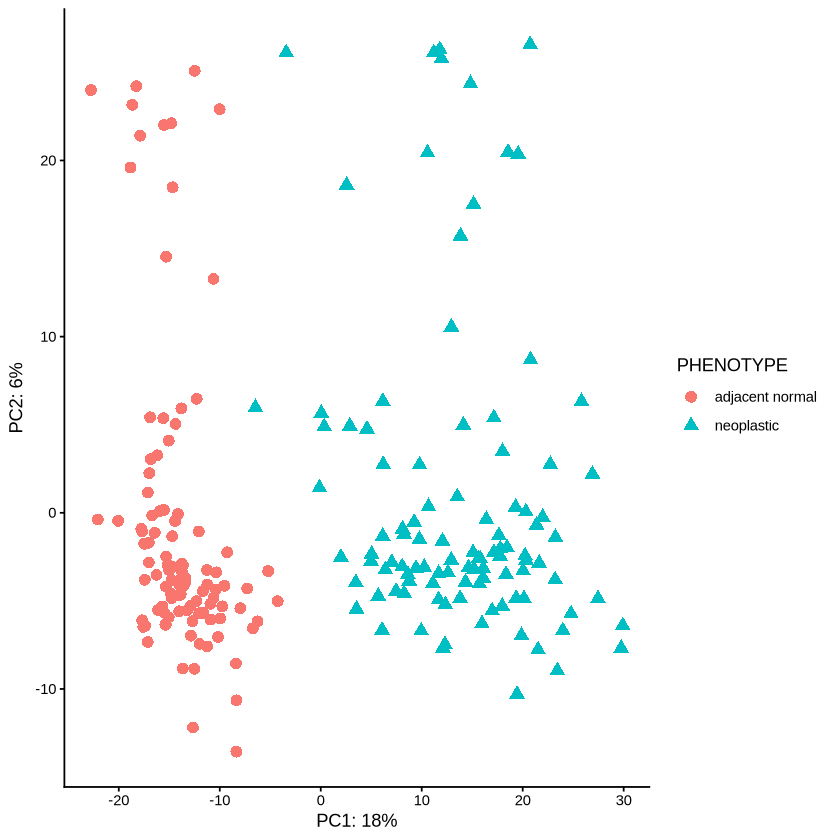

In [190]:
pca_df_mirna <- data.frame(
  PC1 = pca_mirna$x[,1],
  PC2 = pca_mirna$x[,2],
  mirna_metadata
)

ggplot(pca_df_mirna, aes(PC1, PC2,
                   color = .data[[config$external_col]],
                   shape = .data[[config$external_col]])) +
  geom_point(size = 3) +
  xlab(paste0("PC1: ", round(percentVar[1]*100), "%")) +
  ylab(paste0("PC2: ", round(percentVar[2]*100), "%")) +
  theme_classic()

In [20]:
rna_network_dir <- paste0("../", config$rna_network_dir)

In [21]:
rna_network_dir

[1] "../rna_normal_tmm"

In [22]:
# Load the pre-computed WGCNA modules of RNA pooled
sft <- readRDS(paste(rna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

svg(paste0(config$rna_network_dir, "_", cohort, "_sft_rna.svg"))
plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line
dev.off()

pdf 
  2

In [23]:
meanK <- sft$fitIndices[,5]  # mean connectivity

svg(paste0(config$rna_network_dir, "_", cohort, "_meanK_rna.svg"))
plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)
dev.off()

pdf 
  2

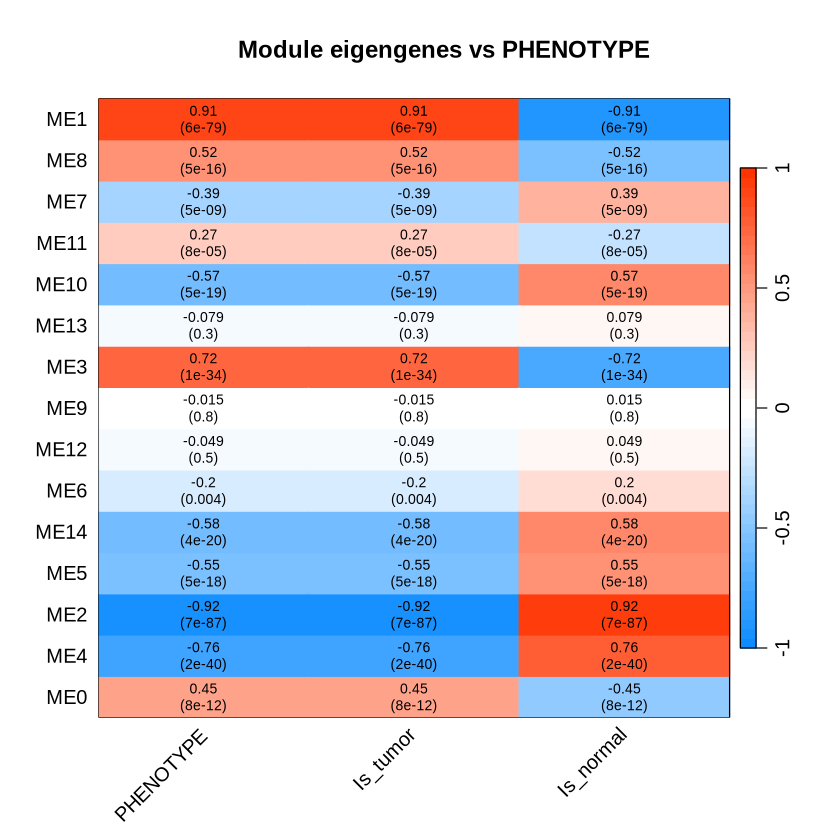

In [195]:
# Load
MEs    <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(rna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!(config$external_col %in% colnames(traits))) stop("External column not found in traits.")

trait_pheno <- traits[, config$external_col, drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno[[config$external_col]])) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno[[config$external_col]]))
  if (length(lev) != 2) {
    stop(paste0(
      "External column must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev) # tumor must be 1 and normal must be 0
  trait_pheno[[config$external_col]] <- ifelse(as.character(trait_pheno[[config$external_col]]) == lev[2], 1, 0) # THIS IF FOR TUMOR=1, NORMAL=0
}

# add new columns: Is_tumor and Is_normal
trait_pheno$Is_tumor <- ifelse(trait_pheno[[config$external_col]] == 1, 1, 0)
trait_pheno$Is_normal <- ifelse(trait_pheno[[config$external_col]] == 1, 0, 1)

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
labeledHeatmap(
  Matrix = MEtraitCor,
  xLabels = c(config$external_col, "Is_tumor", "Is_normal"),
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  main = paste0("Module eigengenes vs ", config$external_col)
)

In [196]:
# 1. Cargamos y sincronizamos (se mantiene igual)
MEs    <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(rna_network_dir, "/datTraits_clean.rds", sep=""))

common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

if (!(config$external_col %in% colnames(traits))) stop("External column not found in traits.")

# Nos quedamos SOLO con la columna del fenotipo
trait_pheno <- traits[, config$external_col, drop = FALSE]

# 2. Conversión a numérico (Normal=0, Tumor=1)
if (!is.numeric(trait_pheno[[config$external_col]])) {
  lev <- sort(unique(as.character(trait_pheno[[config$external_col]])))
  if (length(lev) != 2) stop("Debe haber exactamente 2 niveles.")
  
  # lev[2] suele ser 'Tumor' por orden alfabético si es 'Normal' vs 'Tumor'
  trait_pheno[[config$external_col]] <- ifelse(as.character(trait_pheno[[config$external_col]]) == lev[2], 1, 0)
}

# --- CAMBIO AQUÍ: Eliminamos la creación de Is_tumor e Is_normal ---
# No agregamos más columnas a trait_pheno

# 3. Correlaciones (ahora MEtraitCor tendrá solo 1 columna)
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# 4. Matriz de texto ajustada a la nueva dimensión
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# 5. Gráfico con una sola columna, remove correlation values from the cells
svg("rnatraits.svg")
labeledHeatmap(
  Matrix = MEtraitCor,
  #xLabels = config$external_col, # Solo una etiqueta en el eje X
  xLabels = "Tumoral Status",
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  #main = paste0("Module eigengenes vs ", config$external_col)
  main = paste0("Module eigengenes vs tumoral status")
)
dev.off()

pdf 
  2

In [197]:
# print heatmap as only values
rna_ME_traitcor <- MEtraitCor
write.csv(MEtraitCor, file = paste(rna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [198]:
net <- readRDS(paste(rna_network_dir, "/blockwise_net.rds", sep=""))
rna_net <- net

In [199]:
if (cohort == "TAIWAN") {
    module_genes_pos <- gsub("\\..*", "", names(rna_net$colors[rna_net$colors == 1]))
    module_genes_neg <- gsub("\\..*", "", names(rna_net$colors[rna_net$colors == 2]))
} else if (cohort == "WHITE") {
    module_genes_pos <- gsub("\\..*", "", names(rna_net$colors[rna_net$colors == 1]))
    module_genes_neg <- gsub("\\..*", "", names(rna_net$colors[rna_net$colors == 3]))
}

In [200]:
genes_pos_to_entrez <- bitr(module_genes_pos, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)
genes_neg_to_entrez <- bitr(module_genes_neg, fromType = "ENSEMBL", toType = "ENTREZID", OrgDb = org.Hs.eg.db)

'select()' returned 1:many mapping between keys and columns

Warning message in bitr(module_genes_pos, fromType = "ENSEMBL", toType = "ENTREZID", :
“0.69% of input gene IDs are fail to map...”
'select()' returned 1:many mapping between keys and columns

Warning message in bitr(module_genes_neg, fromType = "ENSEMBL", toType = "ENTREZID", :
“0.79% of input gene IDs are fail to map...”


In [201]:
kegg_results <- enrichKEGG(gene         = genes_pos_to_entrez$ENTREZID,
                        organism     = 'hsa',
                        pvalueCutoff = 0.05)

In [202]:
svg(paste0("kegg_enrichment_pos_", cohort, ".svg"))
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")
dev.off()

pdf 
  2

In [203]:
kegg_results <- enrichKEGG(gene         = genes_neg_to_entrez$ENTREZID,
                        organism     = 'hsa',
                        pvalueCutoff = 0.05)

In [204]:
svg(paste0("kegg_enrichment_neg_", cohort, ".svg"))
dotplot(kegg_results, showCategory=5) + ggtitle("KEGG Pathway Enrichment")
dev.off()

pdf 
  2

In [205]:
ego_pos <- enrichGO(gene          = module_genes_pos,
                keyType      = "ENSEMBL",
                OrgDb         = org.Hs.eg.db,
                ont           = "BP", # Biological Process
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

In [206]:
svg(paste0("go_bp_pos_", cohort, ".svg"))
dotplot(ego_pos, showCategory=5) + ggtitle("GO Biological Processes Enrichment")
dev.off()

pdf 
  2

In [207]:
ego_pos <- enrichGO(gene          = module_genes_pos,
                keyType      = "ENSEMBL",
                OrgDb         = org.Hs.eg.db,
                ont           = "MF",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

In [208]:
svg(paste0("go_mf_pos_", cohort, ".svg"))
dotplot(ego_pos, showCategory=5) + ggtitle("GO Molecular Function Enrichment")
dev.off()

pdf 
  2

In [209]:
ego_pos <- enrichGO(gene          = module_genes_pos,
                keyType      = "ENSEMBL",
                OrgDb         = org.Hs.eg.db,
                ont           = "CC",
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

In [210]:
svg(paste0("go_cc_pos_", cohort, ".svg"))
dotplot(ego_pos, showCategory=5) + ggtitle("GO Cellular Component Enrichment")
dev.off()

pdf 
  2

In [211]:
ego_neg <- enrichGO(gene          = module_genes_neg,
                keyType      = "ENSEMBL",
                OrgDb         = org.Hs.eg.db,
                ont           = "BP", # Biological Process
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

In [212]:
svg(filename = paste0("go_bp_neg_", cohort, ".svg"))
dotplot(ego_neg, showCategory=5) + ggtitle("GO Biological Processes Enrichment")
dev.off()

pdf 
  2

In [213]:
ego_neg <- enrichGO(gene          = module_genes_neg,
                keyType      = "ENSEMBL",
                OrgDb         = org.Hs.eg.db,
                ont           = "MF", # Molecular Function
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

In [214]:
svg(paste0("go_mf_neg_", cohort, ".svg"))
dotplot(ego_neg, showCategory=5) + ggtitle("GO Molecular Function Enrichment")
dev.off()

pdf 
  2

In [215]:
ego_neg <- enrichGO(gene          = module_genes_neg,
                keyType      = "ENSEMBL",
                OrgDb         = org.Hs.eg.db,
                ont           = "CC", # Cellular Component
                pAdjustMethod = "BH",
                pvalueCutoff  = 0.05,
                qvalueCutoff  = 0.05,
                readable      = TRUE)

In [216]:
svg(paste0("go_cc_neg_", cohort, ".svg"))
dotplot(ego_neg, showCategory=5) + ggtitle("GO Cellular Component Enrichment")
dev.off()

pdf 
  2

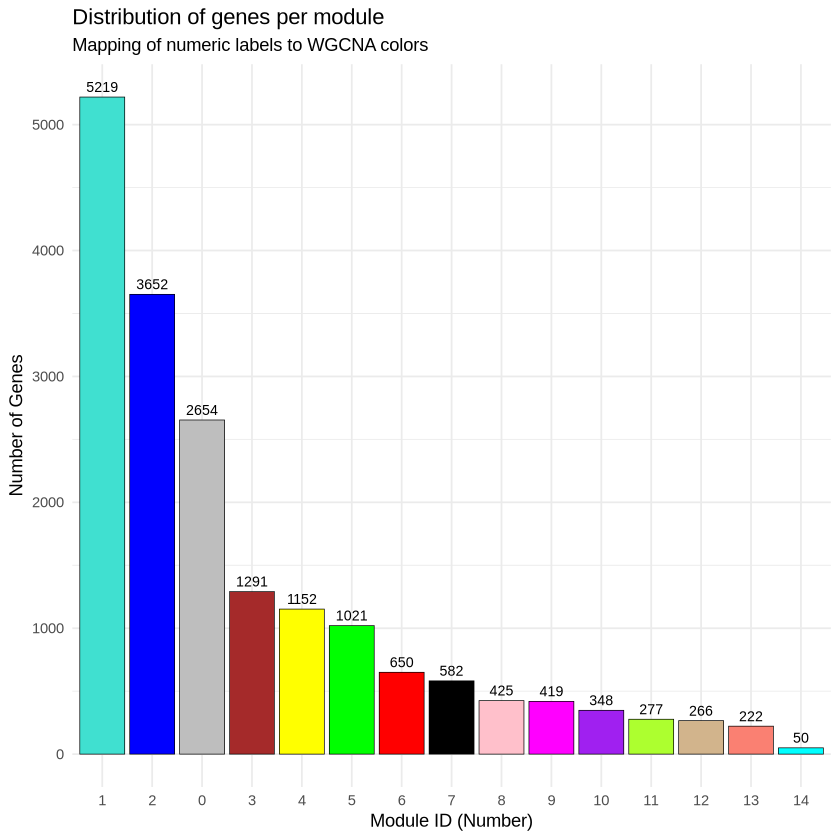

In [217]:
gene_counts <- as.data.frame(table(rna_net$colors))

colnames(gene_counts) <- c("ModuleID", "GeneCount")

# 3. TRADUCCIÓN: Convertir los números a nombres de colores de WGCNA
# Es importante convertir a numérico primero por si el factor da problemas
gene_counts$ActualColor <- labels2colors(as.numeric(as.character(gene_counts$ModuleID)))

# 4. Ordenar de mayor a menor tamaño
gene_counts <- gene_counts %>% 
  arrange(desc(GeneCount))

# 5. Graficar
ggplot(gene_counts, aes(x = reorder(ModuleID, -GeneCount), y = GeneCount, fill = ActualColor)) +
  geom_bar(stat = "identity", color = "black", linewidth = 0.2) +
  
  # Usamos los colores traducidos para el relleno
  scale_fill_identity() +
  
  # Etiquetas con el conteo sobre las barras
  geom_text(aes(label = GeneCount), vjust = -0.5, size = 3) +
  
  labs(title = "Distribution of genes per module",
       subtitle = "Mapping of numeric labels to WGCNA colors",
       x = "Module ID (Number)",
       y = "Number of Genes") +
  
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 0))


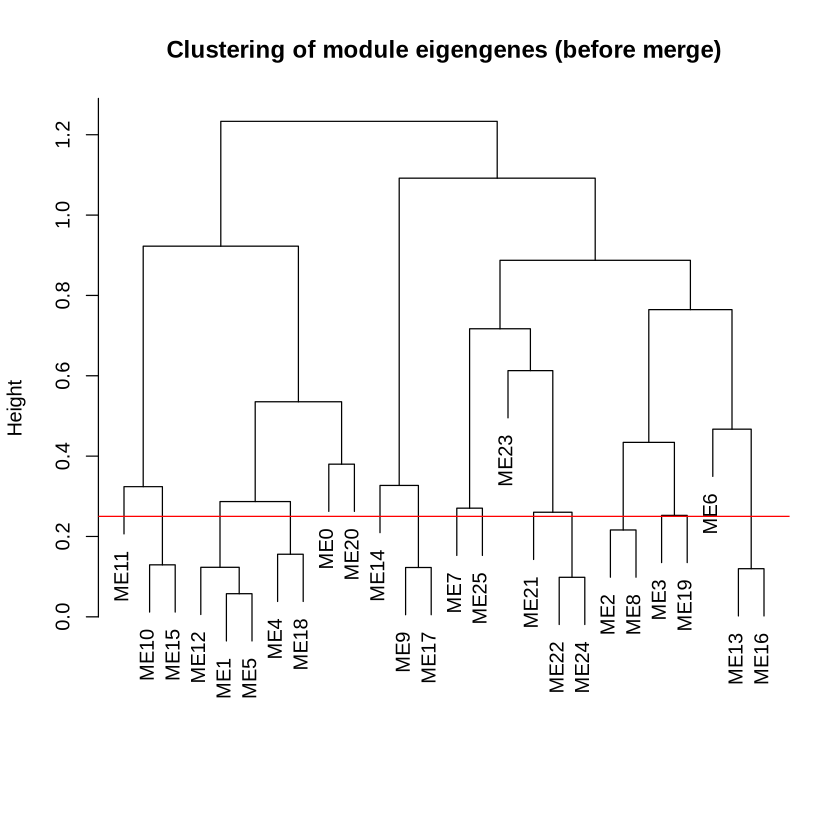

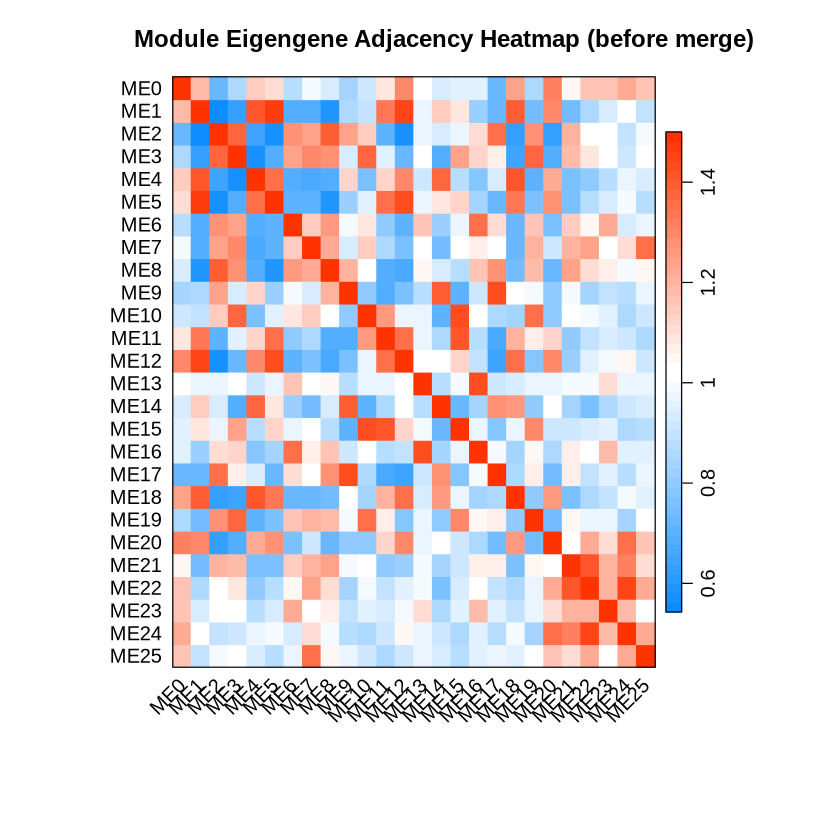

In [218]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.25, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

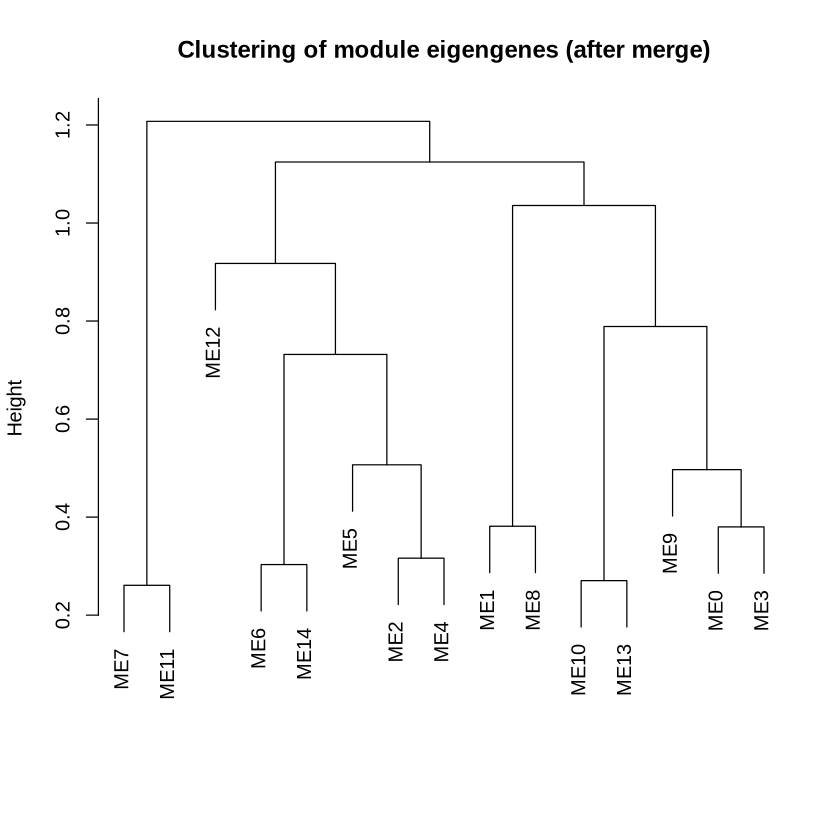

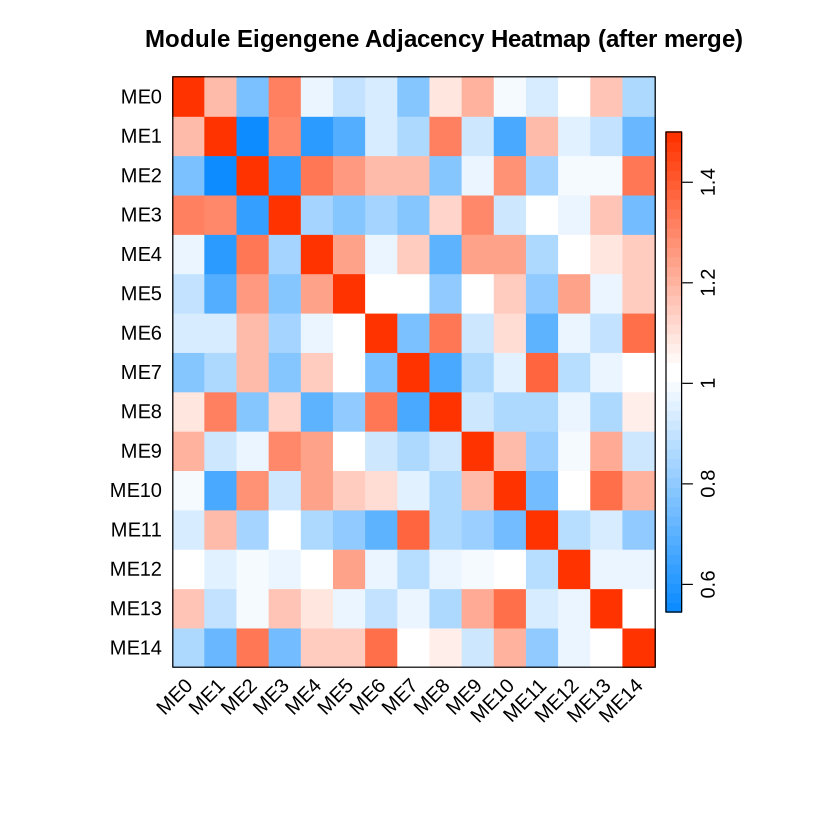

In [219]:
datExpr <- readRDS(paste(rna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [220]:
mirna_network_dir <- paste0("../", config$mirna_network_dir)

In [221]:
# Load the pre-computed WGCNA modules of miRNA pooled
sft <- readRDS(paste(mirna_network_dir, "/softThreshold_sft.rds", sep=""))
powers <- sft$fitIndices[,1]
sftR2  <- -sign(sft$fitIndices[,3]) * sft$fitIndices[,2]  # signed R^2

svg(paste0(config$mirna_network_dir, "_", cohort, "_sft_mirna.svg"))
plot(powers, sftR2,
     xlab="Soft Threshold (power)",
     ylab="Scale Free Topology Model Fit, signed R^2",
     type="n", main="Scale-free fit")
text(powers, sftR2, labels=powers, cex=0.8)
abline(h=0.80, lty=2)  # common reference line
dev.off()

pdf 
  2

In [222]:
meanK <- sft$fitIndices[,5]  # mean connectivity

svg(paste0(config$mirna_network_dir, "_meanK_mirna.svg"))
plot(powers, meanK,
     xlab="Soft Threshold (power)",
     ylab="Mean connectivity",
     type="n", main="Mean connectivity")
text(powers, meanK, labels=powers, cex=0.8)
dev.off()

pdf 
  2

In [223]:
# Load
MEs    <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))
traits <- readRDS(paste(mirna_network_dir, "/datTraits_clean.rds", sep=""))

# Match samples (same order)
common <- intersect(rownames(MEs), rownames(traits))
MEs    <- MEs[common, , drop = FALSE]
traits <- traits[common, , drop = FALSE]

# Use ONLY PHENOTYPE
if (!(config$external_col %in% colnames(traits))) stop("External column not found in traits.")

trait_pheno <- traits[, config$external_col, drop = FALSE]

# Convert PHENOTYPE to numeric safely
# Case A: already numeric (0/1)
if (is.numeric(trait_pheno[[config$external_col]])) {
  # keep as is
} else {
  lev <- unique(as.character(trait_pheno[[config$external_col]]))
  if (length(lev) != 2) {
    stop(paste0(
      "External col must have exactly 2 levels for this heatmap. Found: ",
      paste(sort(lev), collapse = ", ")
    ))
  }
  # Map alphabetically: first level -> 0, second -> 1 (change if you want Tumor=1)
  lev <- sort(lev)
  trait_pheno[[config$external_col]] <- ifelse(as.character(trait_pheno[[config$external_col]]) == lev[2], 1, 0)
}

# Correlations + p-values
MEtraitCor    <- cor(MEs, trait_pheno, use = "p")
MEtraitPvalue <- corPvalueStudent(MEtraitCor, nSamples = nrow(MEs))

# Text matrix
textMatrix <- paste0(signif(MEtraitCor, 2), "\n(", signif(MEtraitPvalue, 1), ")")
dim(textMatrix) <- dim(MEtraitCor)

# Plot
svg("mirnatraits.svg")
labeledHeatmap(
  Matrix = MEtraitCor,
  #xLabels = config$external_col,
  xLabels = "Tumoral Status",
  yLabels = colnames(MEs),
  ySymbols = colnames(MEs),
  colorLabels = FALSE,
  colors = blueWhiteRed(50),
  textMatrix = textMatrix,
  setStdMargins = FALSE,
  cex.text = 0.7,
  zlim = c(-1, 1),
  #main = paste0("Module eigengenes vs ", config$external_col)
  main = paste0("Module eigengenes vs tumoral status")
)
dev.off()

pdf 
  2

In [224]:
miRNA_traitCor <- MEtraitCor
write.csv(MEtraitCor, file = paste(mirna_network_dir, "/ME_trait_correlation_values.csv", sep=""))

In [225]:
net <- readRDS(paste(mirna_network_dir, "/blockwise_net.rds", sep=""))
mirna_net <- net

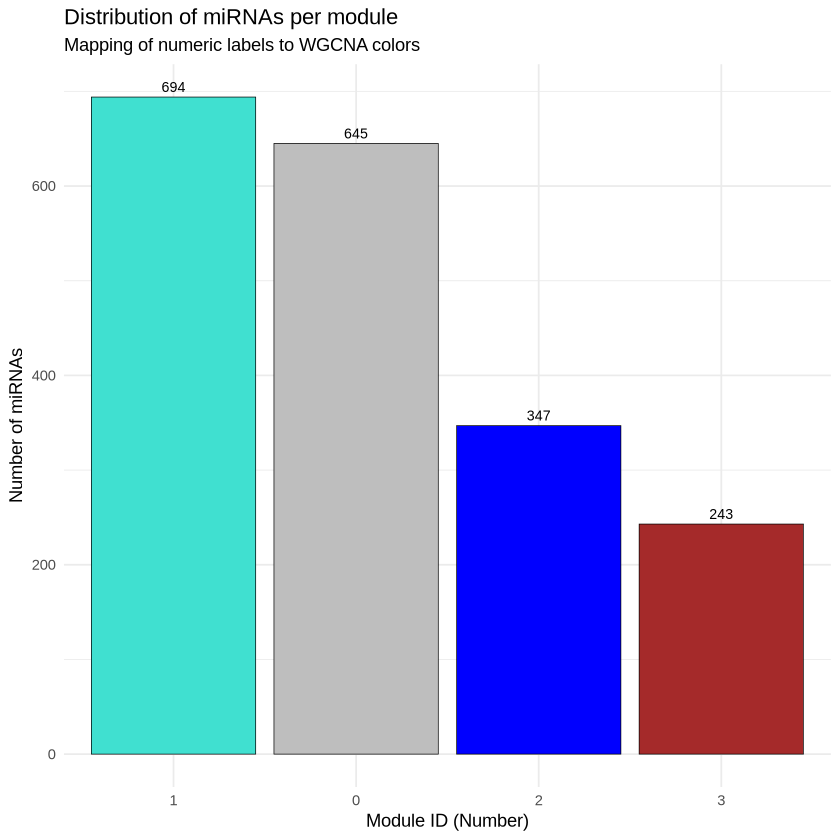

In [226]:
gene_counts <- as.data.frame(table(mirna_net$colors))

colnames(gene_counts) <- c("ModuleID", "GeneCount")

# 3. TRADUCCIÓN: Convertir los números a nombres de colores de WGCNA
# Es importante convertir a numérico primero por si el factor da problemas
gene_counts$ActualColor <- labels2colors(as.numeric(as.character(gene_counts$ModuleID)))

# 4. Ordenar de mayor a menor tamaño
gene_counts <- gene_counts %>% 
  arrange(desc(GeneCount))

# 5. Graficar
ggplot(gene_counts, aes(x = reorder(ModuleID, -GeneCount), y = GeneCount, fill = ActualColor)) +
  geom_bar(stat = "identity", color = "black", linewidth = 0.2) +
  
  # Usamos los colores traducidos para el relleno
  scale_fill_identity() +
  
  # Etiquetas con el conteo sobre las barras
  geom_text(aes(label = GeneCount), vjust = -0.5, size = 3) +
  
  labs(title = "Distribution of miRNAs per module",
       subtitle = "Mapping of numeric labels to WGCNA colors",
       x = "Module ID (Number)",
       y = "Number of miRNAs") +
  
  theme_minimal() +
  theme(axis.text.x = element_text(angle = 0))


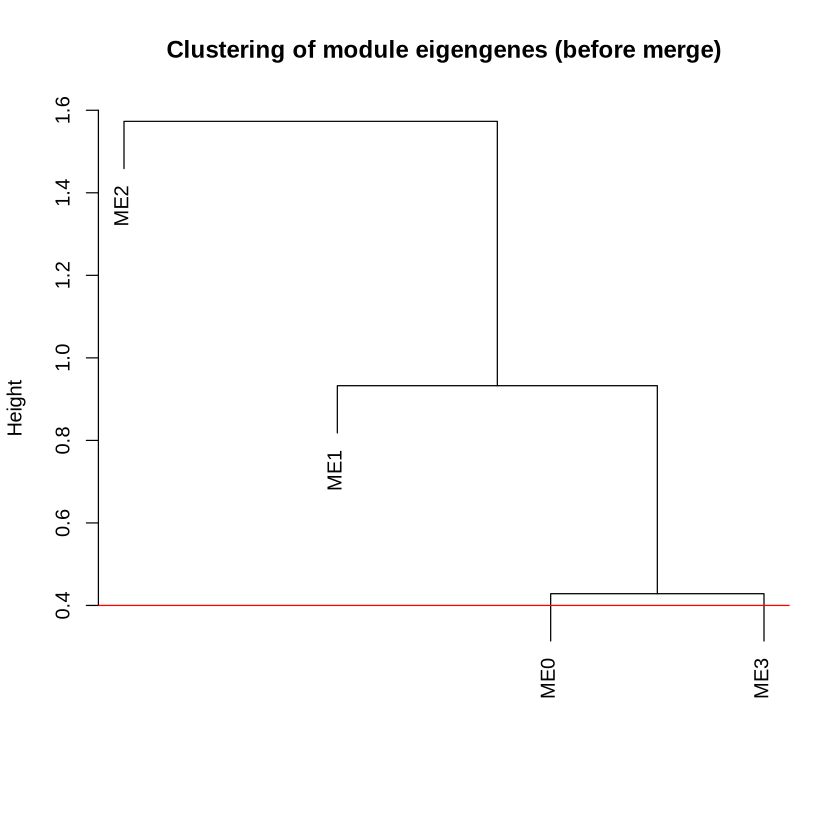

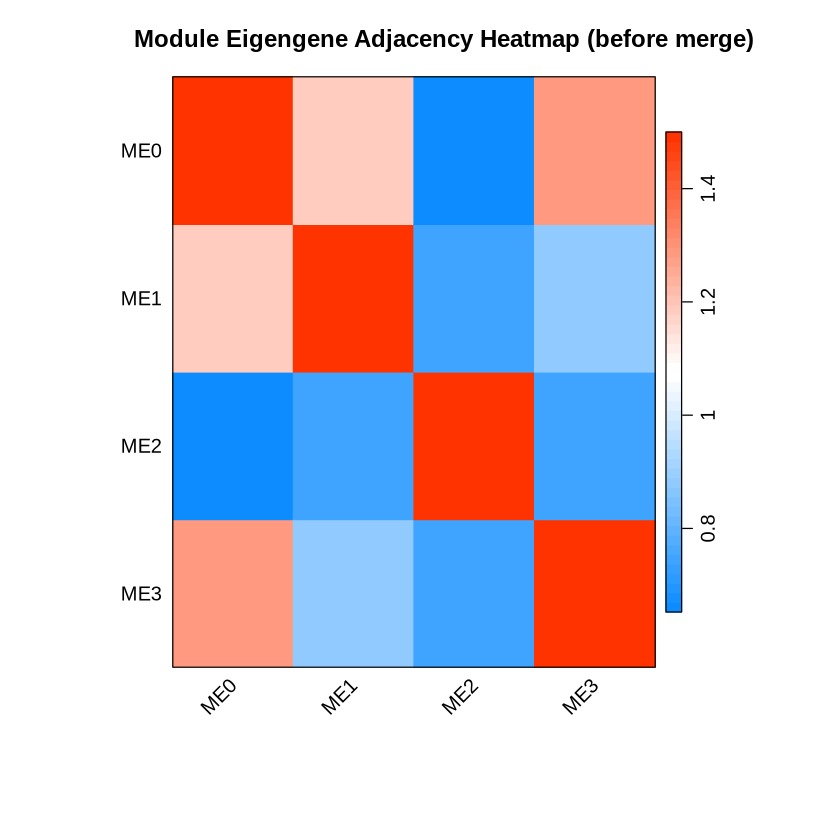

In [227]:
# Visualize the clustering of module eigengenes before merging
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$unmergedColors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (before merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 abline(h = 0.4, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (before merge)",
               colors = blueWhiteRed(50))

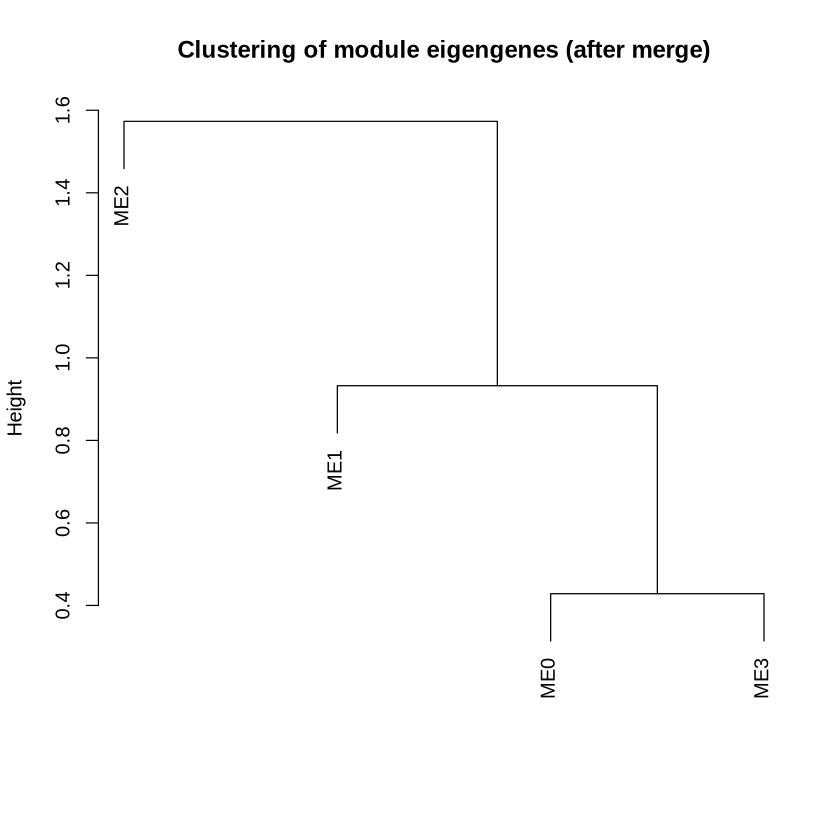

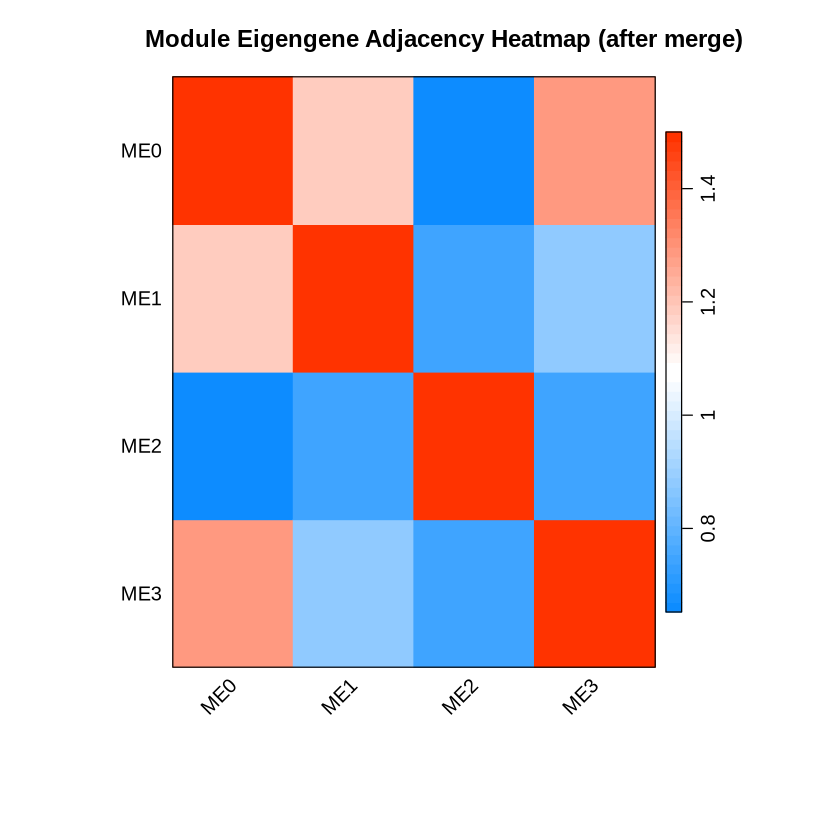

In [228]:
datExpr <- readRDS(paste(mirna_network_dir, "/datExpr_clean.rds", sep=""))
dynamicColors <- net$colors
# 1. Calculate module eigengenes
MEList = moduleEigengenes(datExpr, colors = dynamicColors)
MEs = MEList$eigengenes

# 2. Calculate dissimilarity between module eigengenes (1 - correlation)
MEDiss = 1 - cor(MEs)

# 3. Perform hierarchical clustering
METree = hclust(as.dist(MEDiss), method = "average")

# 4. Plot the dendrogram
plot(METree, main = "Clustering of module eigengenes (after merge)",
     xlab = "", sub = "")
# An optional line can show a potential merge threshold
 #abline(h = 0.45, col = "red")

# 5. Visualize the eigengene adjacency heatmap
# Red signifies high correlation, blue signifies low correlation.
MEadjacency = 1 + cor(MEs) / 2
labeledHeatmap(Matrix = MEadjacency,
               xLabels = names(MEs),
               yLabels = names(MEs),
               main = "Module Eigengene Adjacency Heatmap (after merge)",
               colors = blueWhiteRed(50))

In [229]:
filter_genes <- function(df, kme_limit, kme_p_limit, gs_limit, gs_p_limit) {
  
  # 1. Identificar automáticamente las columnas kME (los valores de correlación)
  # Buscamos columnas que empiecen con kME_ME y terminen en un número (no en _P)
  cols_kme <- grep("^kME_ME\\d+$", colnames(df), value = TRUE)
  
  message("Módulos detectados para el filtro: ", paste(cols_kme, collapse = ", "))

  # 3. Aplicar el filtro dinámico
  df_filtrado <- df %>%
    # Filtro de Fenotipo (GS)
    filter(abs(.data[[paste0("GS_", config$external_col)]]) > gs_limit & .data[[paste0("GS_", config$external_col, "_P")]] < gs_p_limit) %>%
    
    # Filtro de Membresía (kME) horizontal
    rowwise() %>%
    filter({
      # Verificamos si existe algún par (kME, kME_P) que cumpla la condición
      any(sapply(cols_kme, function(col) {
        p_col <- paste0(col, "_P")
        
        # Validación de seguridad: verificar que la columna _P exista en el df
        if (!p_col %in% colnames(df)) return(FALSE)
        
        val_kme <- get(col)
        val_p   <- get(p_col)
        
        # El gen debe cumplir ambos criterios en el MISMO módulo
        !is.na(val_kme) && abs(val_kme) > kme_limit && 
        !is.na(val_p)   && val_p < kme_p_limit
      }))
    }) %>%
    ungroup()

  return(as.data.frame(df_filtrado))
}

In [230]:
MEs_rna <- readRDS(paste(rna_network_dir, "/MEs.rds", sep=""))
MEs_mirna <- readRDS(paste(mirna_network_dir, "/MEs.rds", sep=""))

In [231]:
# get list modules with |r| > thresh with PHENOTYPE from miRNA_traitCor and rna_ME_traitcor #miRNA_traitCor #rna_ME_traitcor

cor_thresh <- 0
MEs_rna <- rna_ME_traitcor[which(abs(rna_ME_traitcor[,1]) > cor_thresh), , drop=FALSE]
MEs_mirna <- miRNA_traitCor[which(abs(miRNA_traitCor[,1]) > cor_thresh), , drop=FALSE]

# remove ME0 from MEs_rna and MEs_mirna
MEs_rna <- MEs_rna[!rownames(MEs_rna) %in% "ME0", , drop=FALSE]
MEs_mirna <- MEs_mirna[!rownames(MEs_mirna) %in% "ME0", , drop=FALSE]

# REMOVE ME from the name
rownames(MEs_rna) <- gsub("ME", "", rownames(MEs_rna))
rownames(MEs_mirna) <- gsub("ME", "", rownames(MEs_mirna))

MEs_rna <- as.data.frame(MEs_rna)
MEs_rna$moduleNumber <- rownames(MEs_rna)

MEs_mirna <- as.data.frame(MEs_mirna)
MEs_mirna$moduleNumber <- rownames(MEs_mirna)

# hasta aca se tienen los listados de modules significativos para rna y miRNA en moduleNumber

# reemplazar cada moduleNumber por kME_ME_number para poder hacer el merge
MEs_rna$kme_ME_number <- paste("kME_ME", MEs_rna$moduleNumber, sep="")
MEs_mirna$kme_ME_number <- paste("kME_ME", MEs_mirna$moduleNumber, sep="")


# List of which to keep (will be all of them if cor_thresh = 0)
kMEs_keep_rna <- MEs_rna$kme_ME_number
KMEs_P_keep_rna <- paste(kMEs_keep_rna, "_P", sep="")
GS_keep_rna <- c(paste0("GS_", config$external_col), paste0("GS_", config$external_col, "_P"))

kMEs_keep_mirna <- MEs_mirna$kme_ME_number
KMEs_P_keep_mirna <- paste(kMEs_keep_mirna, "_P", sep="")
GS_keep_mirna <- c(paste0("GS_", config$external_col), paste0("GS_", config$external_col, "_P"))

In [232]:
# kME tables
kme_table_rna <- readRDS(paste(rna_network_dir, "/kME_table.rds", sep=""))
kme_table_rna_P <- readRDS(paste(rna_network_dir, "/kME_P_table.rds", sep=""))

# GS tables
GS_table_rna <- readRDS(paste(rna_network_dir, "/GS_table.rds", sep=""))
GS_table_rna_P <- readRDS(paste(rna_network_dir, "/GS_P_table.rds", sep=""))

# fuse rna tables
rna_table <- cbind(kme_table_rna, kme_table_rna_P, GS_table_rna, GS_table_rna_P)
# drop gene column
rna_table <- rna_table[, c(kMEs_keep_rna, KMEs_P_keep_rna, GS_keep_rna)]
rna_table$gene <- rownames(rna_table)

In [233]:
selected_rna <- filter_genes(rna_table, kme_limit = config$rna_kme_limit, kme_p_limit = config$rna_kme_p_limit, 
                            gs_limit = config$rna_gs_limit, gs_p_limit = config$rna_gs_p_limit)

Módulos detectados para el filtro: kME_ME1, kME_ME8, kME_ME7, kME_ME11, kME_ME10, kME_ME13, kME_ME3, kME_ME9, kME_ME12, kME_ME6, kME_ME14, kME_ME5, kME_ME2, kME_ME4



In [234]:
# kME tables for miRNA
kme_table_mirna <- readRDS(paste(mirna_network_dir, "/kME_table.rds", sep=""))
kme_table_mirna_P <- readRDS(paste(mirna_network_dir, "/kME_P_table.rds", sep=""))

# GS tables for miRNA
GS_table_mirna <- readRDS(paste(mirna_network_dir, "/GS_table.rds", sep=""))
GS_table_mirna_P <- readRDS(paste(mirna_network_dir, "/GS_P_table.rds", sep=""))

# fuse mirna tables
mirna_table <- cbind(kme_table_mirna, kme_table_mirna_P, GS_table_mirna, GS_table_mirna_P)
mirna_table <- mirna_table[, c(kMEs_keep_mirna, KMEs_P_keep_mirna, GS_keep_mirna)]
mirna_table$gene <- rownames(mirna_table)

In [235]:
selected_mirna <- filter_genes(mirna_table, kme_limit = config$mirna_kme_limit, kme_p_limit = config$mirna_kme_p_limit,
                                gs_limit = config$mirna_gs_limit, gs_p_limit = config$mirna_gs_p_limit)

Módulos detectados para el filtro: kME_ME2, kME_ME1, kME_ME3



In [236]:
# METRODO DE FILTRADO ALTERNATIVO: TOP 1000 GENES Y TOP 50 MIRNAS
n_top_genes <- 1000
n_top_mirnas <- 50

gs_p_thresh <- 0.001

# 1. Seleccionar Top Genes
top_genes <- rna_table %>%
  filter(.data[[paste0("GS_", config$external_col, "_P")]] < gs_p_thresh) %>% # GS_P SIGNIFICATIVO!
  arrange(desc(abs(.data[[paste0("GS_", config$external_col)]]))) %>%
  slice_head(n = n_top_genes) %>%
  pull(gene)

# 2. Seleccionar Top miRNAs
top_mirnas <- mirna_table %>%
  filter(.data[[paste0("GS_", config$external_col, "_P")]] < gs_p_thresh) %>%
  arrange(desc(abs(.data[[paste0("GS_", config$external_col)]]))) %>%
  slice_head(n = n_top_mirnas) %>%
  pull(gene)

In [237]:
# 1. Define the column names dynamically based on your config
gs_col   <- paste0("GS_", config$external_col)
gs_p_col <- paste0("GS_", config$external_col, "_P")

# 2. Filter for all significant features (the background)
significant_features <- rna_table %>%
  filter(.data[[gs_p_col]] < gs_p_thresh) %>%
  mutate(abs_GS = abs(.data[[gs_col]]))

# 3. Calculate the threshold value (the GS of the 1000th gene)
# We sort descending and pick the value at the 'n_top_genes' position
threshold_val <- significant_features %>%
  arrange(desc(abs_GS)) %>%
  slice(n_top_genes) %>%
  pull(abs_GS) %>%
  min() # min() ensures we get the exact boundary

# 4. Create the plot
svg("gs_dist_genes.svg")
ggplot(significant_features, aes(x = abs_GS)) +
  # Draw the histogram of all significant genes
  geom_histogram(binwidth = 0.02, fill = "grey70", color = "white", alpha = 0.8) +
  # Add a vertical line at the threshold
  geom_vline(xintercept = threshold_val, linetype = "dashed", color = "firebrick", size = 1) +
  # Add a label for the threshold
  annotate("text", x = threshold_val + 0.02, y = 5, 
           label = paste("Top", n_top_genes, "Threshold"), 
           angle = 90, color = "firebrick", hjust = 0, fontface = "bold") +
  # Aesthetics
  labs(
    #title = paste("Distribution of Significant Gene Significance (", config$external_col, ")"),
    title = paste("Distribution of Significant Gene Significance (Tumoral Status)"),
    subtitle = paste("Reference line marks the top", n_top_genes, "genes by absolute GS"),
    x = "|Gene Significance|",
    y = paste0("Count (Genes with p < ", gs_p_thresh, ")")
  ) +
  theme_minimal()
dev.off()

pdf 
  2

In [238]:
# 1. Define the column names dynamically based on your config
gs_col   <- paste0("GS_", config$external_col)
gs_p_col <- paste0("GS_", config$external_col, "_P")

# 2. Filter for all significant features (the background)
significant_features <- mirna_table %>%
  filter(.data[[gs_p_col]] < gs_p_thresh) %>%
  mutate(abs_GS = abs(.data[[gs_col]]))

# 3. Calculate the threshold value (the GS of the 1000th gene)
# We sort descending and pick the value at the 'n_top_genes' position
threshold_val <- significant_features %>%
  arrange(desc(abs_GS)) %>%
  slice(n_top_mirnas) %>%
  pull(abs_GS) %>%
  min() # min() ensures we get the exact boundary

# 4. Create the plot
svg("gs_dist_mirnas.svg")
ggplot(significant_features, aes(x = abs_GS)) +
  # Draw the histogram of all significant genes
  geom_histogram(binwidth = 0.02, fill = "grey70", color = "white", alpha = 0.8) +
  # Add a vertical line at the threshold
  geom_vline(xintercept = threshold_val, linetype = "dashed", color = "firebrick", size = 1) +
  # Add a label for the threshold
  annotate("text", x = threshold_val + 0.02, y = 5, 
           label = paste("Top", n_top_mirnas, "Threshold"), 
           angle = 90, color = "firebrick", hjust = 0, fontface = "bold") +
  # Aesthetics
  labs(
    #title = paste("Distribution of Significant Gene Significance (", config$external_col, ")"),
    title = paste("Distribution of Significant Gene Significance (Tumoral Status)"),
    subtitle = paste("Reference line marks the top", n_top_mirnas, "genes by absolute GS"),
    x = "|Gene Significance|",
    y = paste0("Count (Genes with p < ", gs_p_thresh, ")")
  ) +
  theme_minimal()
dev.off()

pdf 
  2

In [239]:
length(top_genes)
length(top_mirnas)

[1] 1000

[1] 50

In [240]:
# write the top genes and top mirnas to files
write.table(top_genes, file="top_genes.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)
write.table(top_mirnas, file="top_mirnas.txt", quote=FALSE, row.names=FALSE, col.names=FALSE)

In [241]:
# write to a csv the rna_table and mirna_table
write.csv(rna_table, file="rna_table.csv")
write.csv(mirna_table, file="mirna_table.csv")

In [242]:
dist_rna <- prepare_module_dist(rna_net, top_genes, "mRNAs (Top 1000)")
dist_mirna <- prepare_module_dist(mirna_net, top_mirnas, "miRNAs (Top 500)")

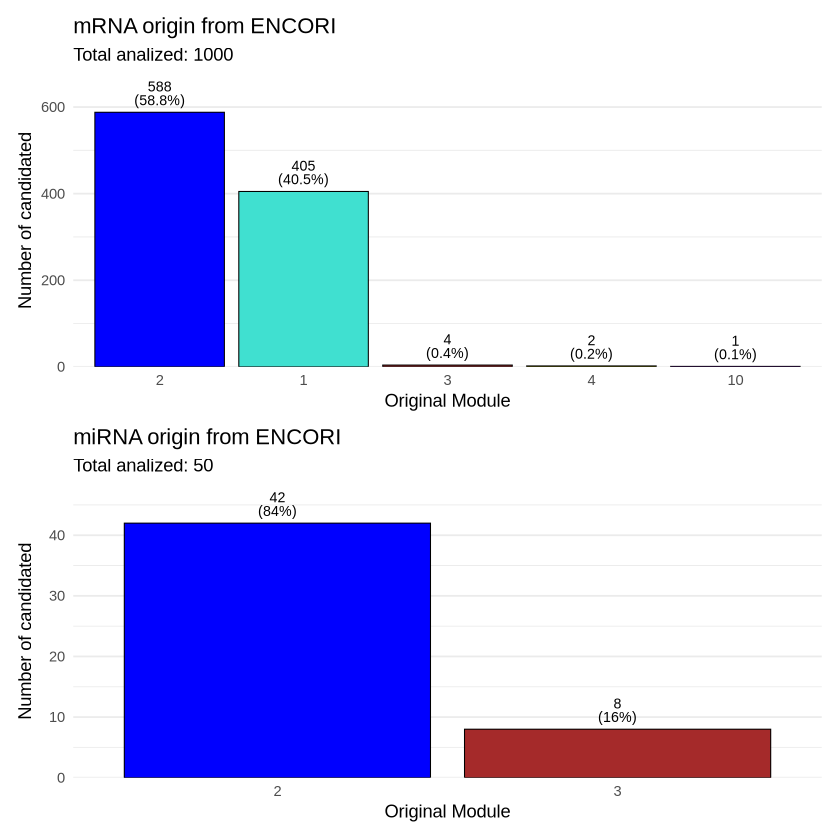

In [243]:
plot_dist <- function(df, title) {
  # Calculamos el porcentaje total del dataframe
  total <- sum(df$Count)
  
  ggplot(df, aes(x = reorder(ModuleID, -Count), y = Count, fill = Color)) +
    geom_bar(stat = "identity", color = "black", linewidth = 0.3) +
    scale_fill_identity() +
    # Modificamos geom_text para que muestre: "N (X.X%)"
    geom_text(aes(label = paste0(Count, "\n(", round((Count / total) * 100, 1), "%)")), 
              vjust = -0.3,    # Ajuste vertical para que no choque con la barra
              size = 3,       # Tamaño de la fuente
              lineheight = 0.8) + # Espacio entre el número y el porcentaje
    labs(title = title, 
         subtitle = paste("Total analized:", total),
         x = "Original Module", 
         y = "Number of candidated") +
    # Expandimos un poco el eje Y para que el texto de arriba no se corte
    scale_y_continuous(expand = expansion(mult = c(0, 0.15))) + 
    theme_minimal() +
    theme(panel.grid.major.x = element_blank()) # Limpiamos un poco el fondo
}

# Luego ejecutas lo mismo que ya tenías:
p1 <- plot_dist(dist_rna, "mRNA origin from ENCORI")
p2 <- plot_dist(dist_mirna, "miRNA origin from ENCORI")

p1 / p2

In [244]:
# load ENCORI dataframe
encori_filtered <- read_tsv("../../ENCORI_hg38_miRNA-mRNA_FILTERED.tsv")

Rows: 219690 Columns: 27
── Column specification ────────────────────────────────────────────────────────
Delimiter: "\t"
chr  (9): miRNAid, miRNAname, geneID, geneName, geneType, chromosome, strand...
dbl (18): narrowStart, narrowEnd, broadStart, broadEnd, clipExpNum, degraExp...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [245]:
dim(encori_filtered)

[1] 219690     27

In [246]:
# remove the .XX in the selected_rna genes
# genes_selected_rna_noversion <- gsub("\\.\\d+$", "", selected_rna$gene)
genes_selected_rna_noversion <- gsub("\\.\\d+$", "", top_genes) # COMENTAR O BORRAR SI NO SE QUIERE TOP

In [247]:
# Tamaño del ENCORI que estoy cargando
length(unique(encori_filtered$geneID))
length(unique(encori_filtered$miRNAname))

[1] 11237

[1] 205

In [248]:
if (cohort == "TAIWAN") {
    mirnas <- miRNAVersionConvert(selected_mirna$gene, targetVersion = "v22", exact=TRUE)$Accession
    mirnas <- miRNAVersionConvert(top_mirnas, targetVersion = "v22", exact=TRUE)$Accession # COMENTAR SI NO SE QUIERE TRABAJAR CON EL TOP
} else if (cohort == "WHITE") {
    #mirnas <- selected_mirna$gene    
    mirnas <- top_mirnas # COMENTAR SI NO SE QUIERE TRABAJAR CON EL TOP
}

In [249]:
edges_selected <- encori_filtered %>%
  filter(
    geneID %in% genes_selected_rna_noversion &
    miRNAid %in% mirnas
  )

In [250]:
dim(edges_selected)

[1] 1570   27

In [251]:
unique_encori <- edges_selected %>%
  group_by(miRNAid, geneID) %>%
  summarise(
    weight = n(), # Cuenta cuántas veces aparece el par
    .groups = 'drop'
  )

In [252]:
dim(unique_encori)
length(unique(unique_encori$miRNAid))
length(unique(unique_encori$geneID))

[1] 1187    3

[1] 15

[1] 474

In [253]:
genes_encori <- unique_encori$geneID
mirnas_encori <- unique_encori$miRNAid

In [254]:
if (cohort == "TAIWAN") {
    mirnas_encori <- miRNA_AccessionToName(unique_encori$miRNAid)$TargetName
}

In [255]:
# 1. Función para limpiar IDs (quitar el .XX)
clean_id <- function(id_vector) {
  # Usa una expresión regular para quitar el punto y todo lo que sigue
  return(gsub("\\..*", "", id_vector))
}

# 2. Cargar tus datos de red y tus listas post-ENCORI
# net_rna <- readRDS("rna_blockwise_net.rds")
# genes_encori <- c("ENSG00000139618", "ENSG00000105397") # Ejemplo: IDs ya limpios

# 3. Crear un "Diccionario" de la red original
# Esto mapea el ID limpio al Módulo original
rna_map <- data.frame(
  OriginalID = names(rna_net$colors),
  CleanID = clean_id(names(rna_net$colors)),
  ModuleID = rna_net$colors
)

mirna_map <- data.frame(
  OriginalID = names(mirna_net$colors),
  CleanID = clean_id(names(mirna_net$colors)),
  ModuleID = mirna_net$colors
)

# 4. Función para cruzar los datos y preparar el gráfico
prepare_encori_dist <- function(mapping_df, encori_ids, title_type) {
  # Buscamos qué módulos corresponden a los IDs que sobrevivieron a ENCORI
  hits <- mapping_df %>%
    filter(CleanID %in% encori_ids)
  
  df_plot <- as.data.frame(table(hits$ModuleID))
  colnames(df_plot) <- c("ModuleID", "Count")
  
  # Traducir a colores de WGCNA
  df_plot$Color <- labels2colors(as.numeric(as.character(df_plot$ModuleID)))
  
  # Calcular porcentajes para el gráfico
  total <- sum(df_plot$Count)
  df_plot$Percentage <- (df_plot$Count / total) * 100
  
  df_plot <- df_plot %>% arrange(desc(Count))
  df_plot$Type <- title_type
  return(df_plot)
}

# 5. Procesar los que sobrevivieron al filtro
dist_rna_encori <- prepare_encori_dist(rna_map, genes_encori, "mRNAs (Post-ENCORI)")
dist_mirna_encori <- prepare_encori_dist(mirna_map, mirnas_encori, "miRNAs (Post-ENCORI)")

# 6. Generar los gráficos con etiquetas de porcentaje
plot_final <- function(df, title) {
  ggplot(df, aes(x = reorder(ModuleID, -Count), y = Count, fill = Color)) +
    geom_bar(stat = "identity", color = "black", linewidth = 0.3) +
    scale_fill_identity() +
    # Mostramos el conteo y el porcentaje sobre la barra
    geom_text(aes(label = paste0(Count, "\n(", round(Percentage, 1), "%)")), 
              vjust = -0.2, size = 3, lineheight = 0.8) +
    labs(title = title, 
         subtitle = paste("Total of filtered elements:", sum(df$Count)),
         x = "Original Module (WGCNA)", 
         y = "Frequency") +
    theme_minimal() +
    ylim(0, max(df$Count) * 1.2) # Space for the labels
}

p_rna <- plot_final(dist_rna_encori, "mRNA origin validated by ENCORI")
p_mirna <- plot_final(dist_mirna_encori, "miRNA origin validated by ENCORI")

svg("fig2.svg")
p_rna / p_mirna
dev.off()

pdf 
  2

In [256]:
# genes encori y mirnas encori
df_rna$in_ENCORI <- rownames(df_rna) %in% genes_encori
df_mirna$in_ENCORI <- rownames(df_mirna) %in% mirnas_encori

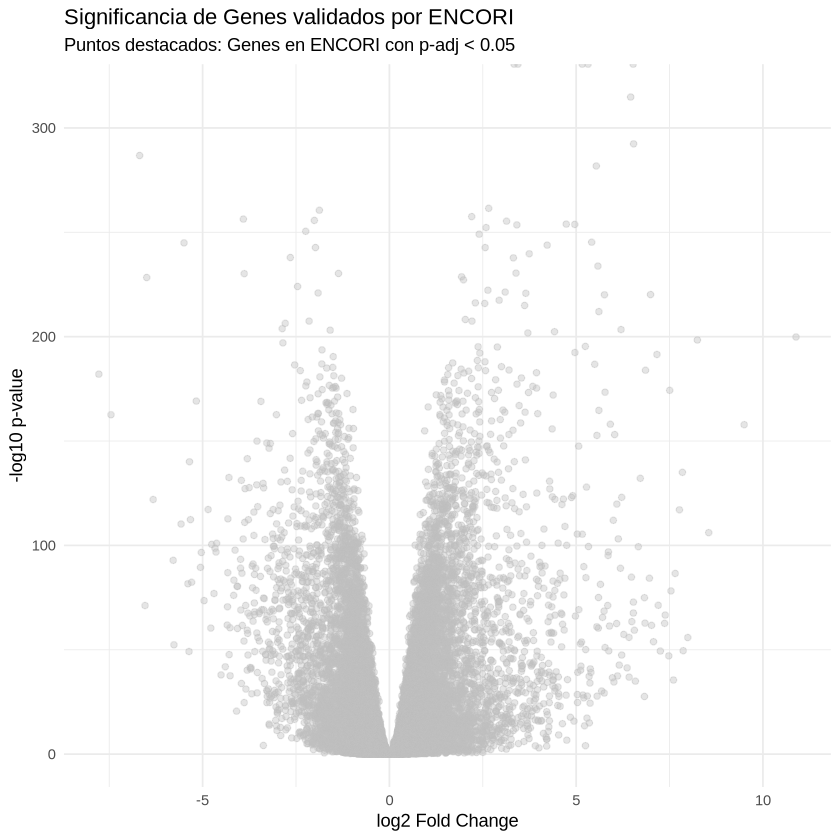

In [257]:
ggplot(df_rna, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(alpha = 0.4, color = "grey") + # Todos los genes en gris
  geom_point(data = subset(df_rna, in_ENCORI == TRUE & padj < 0.001), 
             aes(color = log2FoldChange > 4), size = 2) + # Solo genes ENCORI significativos
  scale_color_manual(values = c("blue", "red"), labels = c("Down", "Up")) +
  labs(title = "Significancia de Genes validados por ENCORI",
       subtitle = "Puntos destacados: Genes en ENCORI con p-adj < 0.05",
       x = "log2 Fold Change", y = "-log10 p-value") +
  theme_minimal()

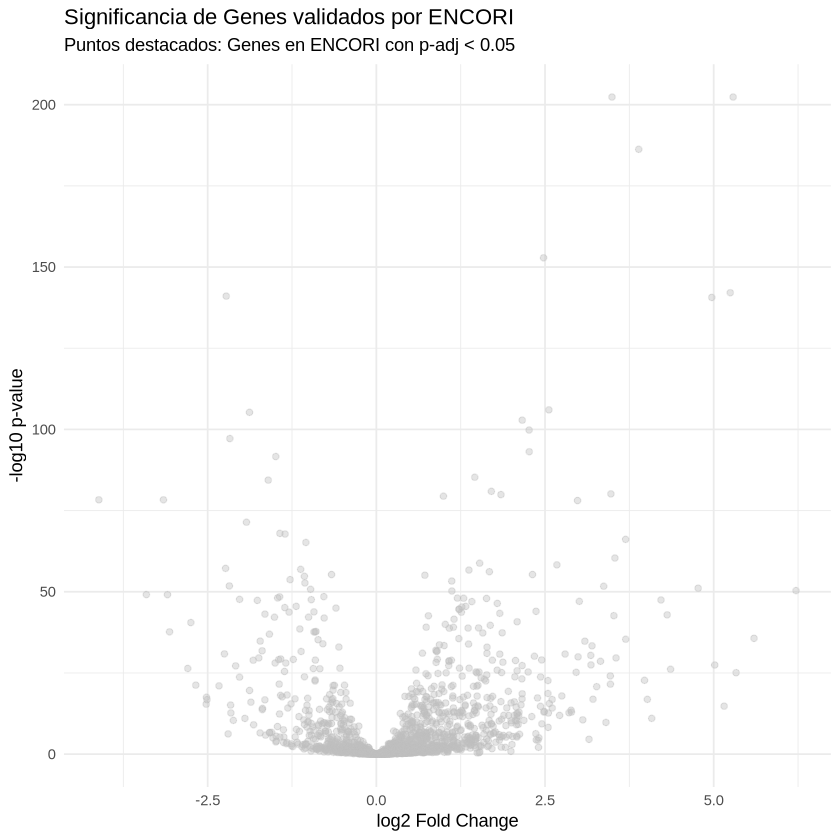

In [258]:
ggplot(df_mirna, aes(x = log2FoldChange, y = -log10(padj))) +
  geom_point(alpha = 0.4, color = "grey") + # Todos los genes en gris
  geom_point(data = subset(df_mirna, in_ENCORI == TRUE & padj < 0.001), 
             aes(color = log2FoldChange > 4), size = 2) + # Solo genes ENCORI significativos
  scale_color_manual(values = c("blue", "red"), labels = c("Down", "Up")) +
  labs(title = "Significancia de Genes validados por ENCORI",
       subtitle = "Puntos destacados: Genes en ENCORI con p-adj < 0.05",
       x = "log2 Fold Change", y = "-log10 p-value") +
  theme_minimal()

In [259]:
rownames(df_rna) <- gsub("\\.\\d+$", "", rownames(df_rna))
df_rna <- as.data.frame(df_rna)
df_mirna <- as.data.frame(df_mirna)

In [260]:
# 1. Obtener TODOS los nodos que existen en la red de ENCORI
# Combinamos la columna de miRNAs y la de Genes para tener el universo completo de nodos
nodos_en_red <- data.frame(
  NodeID = unique(c(unique_encori$miRNAid, unique_encori$geneID))
)

# 2. Preparar las tablas de referencia (como diccionarios)
ref_genes <- data.frame(
  NodeID = rownames(df_rna),
  Category = df_rna$Category,
  NodeType_Ref = "Gene"
)

ref_mirnas <- data.frame(
  NodeID = rownames(df_mirna),
  Category = df_mirna$Category,
  NodeType_Ref = "miRNA"
)

# Unimos ambas referencias en una sola tabla de búsqueda
referencia_total <- bind_rows(ref_genes, ref_mirnas)

# 3. Unir el universo de la red con la información disponible
master_node_table <- nodos_en_red %>%
  left_join(referencia_total, by = "NodeID")

# 4. Manejar los NAs
# Si no se encontró en las tablas de expresión, asignamos "NA" o "Not_Found"
master_node_table <- master_node_table %>%
  mutate(
    Category = replace_na(as.character(Category), "NA"),
    # Intentamos adivinar el tipo si no estaba en la tabla (por el nombre del ID)
    NodeType = case_when(
      !is.na(NodeType_Ref) ~ NodeType_Ref,
      grepl("hsa-", NodeID) | grepl("MIMAT", NodeID) ~ "miRNA",
      TRUE ~ "Gene"
    )
  ) %>%
  select(NodeID, Category, NodeType)

In [261]:
#master_node_table # despues anotar: para todos los miRNA usar miRBaseConverter y para todos los genes usar lo de BioMart
# --- PASO 1: Identificar y Separar ---
genes_ids <- master_node_table %>% filter(NodeType == "Gene") %>% pull(NodeID)
mirnas_ids <- master_node_table %>% filter(NodeType == "miRNA") %>% pull(NodeID)

# --- PASO 2: Convertir Genes con BioMart ---
# Conectamos con el servidor de Ensembl
mart <- useMart("ensembl", dataset = "hsapiens_gene_ensembl")

genes_map <- getBM(
  attributes = c("ensembl_gene_id", "external_gene_name"),
  filters = "ensembl_gene_id",
  values = genes_ids,
  mart = mart
)

# --- PASO 3: Convertir miRNAs con miRBaseConverter ---
# Convertimos de MIMAT (Accession) a Name (Mature ID)
mirnas_map <- miRNA_AccessionToName(
  mirnas_ids, 
  targetVersion = "v22"
)

# --- PASO 4: Actualizar la Master Node Table ---
master_node_table_final <- master_node_table %>%
  # Unir nombres de genes
  left_join(genes_map, by = c("NodeID" = "ensembl_gene_id")) %>%
  # Unir nombres de miRNAs
  left_join(mirnas_map, by = c("NodeID" = "Accession")) %>%
  # Crear columna unificada de 'Name'
  mutate(
    NodeName = case_when(
      NodeType == "Gene" ~ external_gene_name,
      NodeType == "miRNA" ~ TargetName,
      TRUE ~ NodeID # Si es NA o no se encontró, dejamos el ID original
    )
  ) %>%
  # Limpiar columnas temporales y dejar el ID y el Name
  select(NodeID, NodeName, Category, NodeType)

In [262]:
head(df_mirna)

,baseMean,log2FoldChange,lfcSE,stat,pvalue,padj,Category,in_ENCORI
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<lgl>
MIMAT0000758,482.16440,3.492309,0.11402759,30.62688,5.370528e-206,4.476335e-203,Up-regulated,FALSE
MIMAT0003333,68.76618,5.288429,0.17255823,30.64722,2.878371e-206,4.476335e-203,Up-regulated,FALSE
MIMAT0004698,46.17781,3.888756,0.13235938,29.38028,9.809346e-190,5.450727e-187,Up-regulated,FALSE
MIMAT0000281,2626.13363,2.478177,0.09307531,26.62551,3.439843e-156,1.433555e-153,Up-regulated,FALSE
MIMAT0000089,1608.83465,5.245207,0.20431839,25.67173,2.418724e-145,8.064026e-143,Up-regulated,FALSE
MIMAT0000731,1238.19045,-2.224760,0.08700510,-25.57045,3.252550e-144,9.036669e-142,Down-regulated,FALSE


In [263]:
head(master_node_table_final)

,NodeID,NodeName,Category,NodeType
,<chr>,<chr>,<chr>,<chr>
1,MIMAT0000082,hsa-miR-26a-5p,Not significant,miRNA
2,MIMAT0000083,hsa-miR-26b-5p,Not significant,miRNA
3,MIMAT0000099,hsa-miR-101-3p,Not significant,miRNA
4,MIMAT0000250,hsa-miR-139-5p,Not significant,miRNA
5,MIMAT0000275,hsa-miR-218-5p,Not significant,miRNA
6,MIMAT0000281,hsa-miR-224-5p,Up-regulated,miRNA


In [264]:
de_ref_rna <- df_rna %>% 
  rownames_to_column("NodeID") %>% 
  select(NodeID, log2FoldChange = log2FoldChange, padj)

de_ref_mirna <- df_mirna %>% 
  rownames_to_column("NodeID") %>% 
  select(NodeID, log2FoldChange = log2FoldChange, padj)

# Combine both DE results into one lookup table
de_lookup <- bind_rows(de_ref_rna, de_ref_mirna)

# 2. Join it to your master table in one single step
master_node_table_final <- master_node_table_final %>%
  left_join(de_lookup, by = "NodeID") %>%
  # 3. Add the 'Sign' column based on the new log2FoldChange, add "not found" if not found
  mutate(Sign = case_when(
    is.na(log2FoldChange) ~ "not found",
    log2FoldChange > 0 ~ "positive",
    log2FoldChange < 0 ~ "negative",
    TRUE ~ "no_change"
  ))

In [265]:
head(master_node_table_final)

,NodeID,NodeName,Category,NodeType,log2FoldChange,padj,Sign
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<chr>
1,MIMAT0000082,hsa-miR-26a-5p,Not significant,miRNA,-1.0048373,6.456555e-43,negative
2,MIMAT0000083,hsa-miR-26b-5p,Not significant,miRNA,-0.6639596,5.025743e-56,negative
3,MIMAT0000099,hsa-miR-101-3p,Not significant,miRNA,-1.0665438,1.720471e-55,negative
4,MIMAT0000250,hsa-miR-139-5p,Not significant,miRNA,-1.8806690,5.428072e-106,negative
5,MIMAT0000275,hsa-miR-218-5p,Not significant,miRNA,-1.5098840,6.666784e-43,negative
6,MIMAT0000281,hsa-miR-224-5p,Up-regulated,miRNA,2.4781773,1.433555e-153,positive


In [266]:
# 5. Guardar para Cytoscape
write.csv(master_node_table_final, "node_annotation_cytoscape.csv", row.names = FALSE)

In [267]:
dim(unique_encori)
write.table(unique_encori, file=paste0("ENCORI_filtered_edges_selected_modules_", cohort, ".tsv"), sep="\t", quote=FALSE, row.names=FALSE, col.names = TRUE)

[1] 1187    3